开始处理和可视化损失数据...
每个文件将被分为 2000 组，每组 10 行，并取每组的最小损失值。

正在读取文件: burgers_mlp.csv (MLP)
-> 数据处理完成，生成 2000 个绘图点。

正在读取文件: burgers_res.csv (ResNet)
-> 数据处理完成，生成 2000 个绘图点。

正在读取文件: burgers_fou.csv (FourierNet)
-> 数据处理完成，生成 2000 个绘图点。


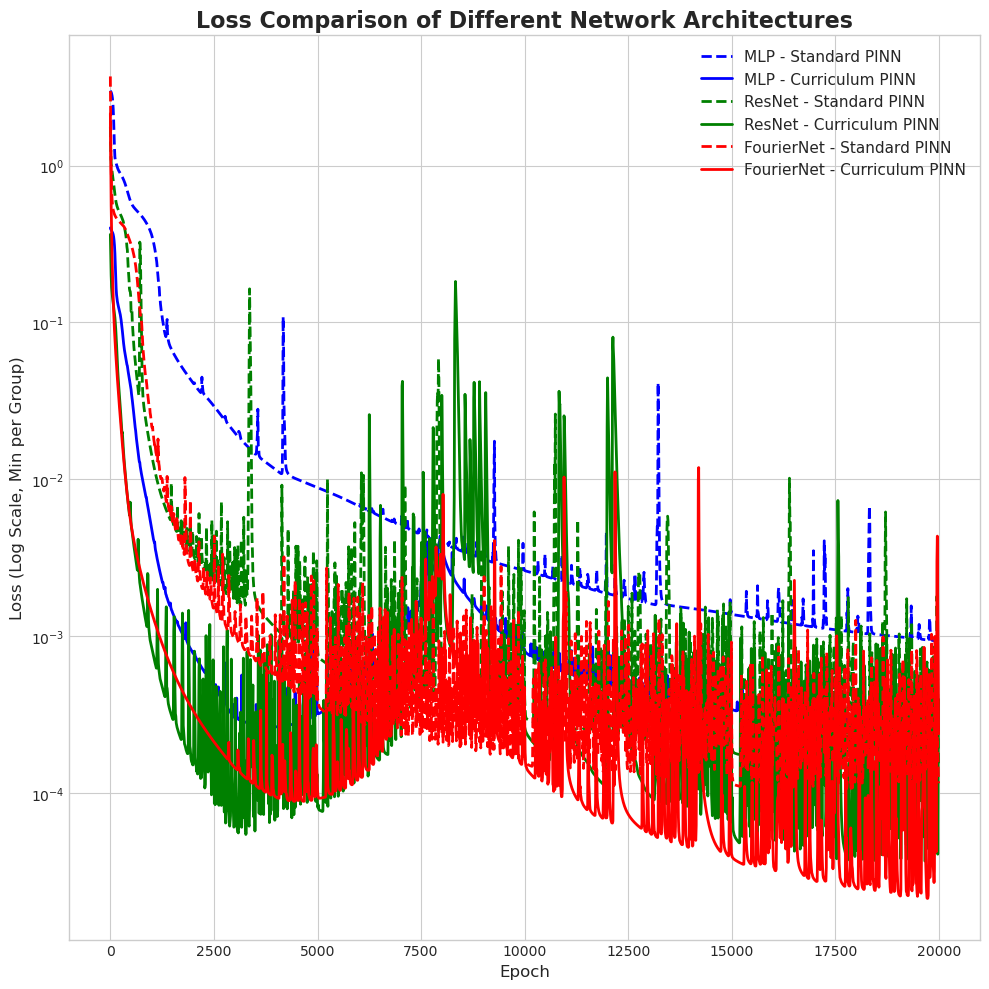


✓ 可视化完成！


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 配置区域 ---

# 1. 定义文件和它们对应的模型名称
#    键是文件名，值是将在图例中显示的名称。
file_map = {
    'burgers_mlp.csv': 'MLP',
    'burgers_res.csv': 'ResNet',
    'burgers_fou.csv': 'FourierNet'
}

# 2. 定义数据分组大小 (每 n 个数据点为一组取最小值)
#    由于有20000行数据，如果n太小，图形会很拥挤。
#    建议使用 50 或 100 来获得更平滑、更清晰的曲线。
#    例如，n=100 意味着每100个epoch取一个最小值点，最终每条线有 20000/100 = 200个点。
GROUP_SIZE = 10

# 3. 定义绘图样式
#    使用颜色区分模型，使用线型区分训练方法
colors = {
    'MLP': 'blue',
    'ResNet': 'green',
    'FourierNet': 'red'
}
linestyles = {
    'Standard PINN': '--',  # 虚线
    'Curriculum PINN': '-'    # 实线
}

# --- 数据处理与绘图 ---

print(f"开始处理和可视化损失数据...")
print(f"每个文件将被分为 {20000 // GROUP_SIZE} 组，每组 {GROUP_SIZE} 行，并取每组的最小损失值。")

# 创建一个方形的图形
plt.style.use('seaborn-v0_8-whitegrid') # 使用一个美观的样式
fig, ax = plt.subplots(figsize=(10, 10))

# 循环遍历每个文件
for filename, model_name in file_map.items():
    try:
        print(f"\n正在读取文件: {filename} ({model_name})")
        
        # 读取CSV文件
        df = pd.read_csv(filename)
        
        # --- 核心处理逻辑：分组并聚合 ---
        # 1. 创建一个分组索引。例如，行0-99为组0，行100-199为组1，以此类推。
        group_indices = np.arange(len(df)) // GROUP_SIZE
        
        # 2. 按此索引对DataFrame进行分组，并计算聚合值：
        #    - 'epoch': 取每组的第一个epoch值作为X轴坐标
        #    - '..._loss': 取每组的最小值
        processed_df = df.groupby(group_indices).agg({
            'epoch': 'first',
            'standard_pinn_loss': 'min',
            'curriculum_pinn_loss': 'min'
        }).reset_index(drop=True)

        print(f"-> 数据处理完成，生成 {len(processed_df)} 个绘图点。")

        # --- 绘图 ---
        # 绘制 Standard PINN 的损失曲线
        ax.plot(
            processed_df['epoch'], 
            processed_df['standard_pinn_loss'],
            label=f'{model_name} - Standard PINN',
            color=colors.get(model_name, 'gray'), # 如果模型名未在colors中定义，则用灰色
            linestyle=linestyles['Standard PINN'],
            linewidth=2
        )
        
        # 绘制 Curriculum PINN 的损失曲线
        ax.plot(
            processed_df['epoch'], 
            processed_df['curriculum_pinn_loss'],
            label=f'{model_name} - Curriculum PINN',
            color=colors.get(model_name, 'black'),
            linestyle=linestyles['Curriculum PINN'],
            linewidth=2
        )

    except FileNotFoundError:
        print(f"[错误] 文件 '{filename}' 未找到，已跳过。请检查文件名和路径。")
    except Exception as e:
        print(f"[错误] 处理文件 '{filename}' 时发生未知错误: {e}")

# --- 图形美化 ---

# 设置Y轴为对数刻度
ax.set_yscale('log')

# 设置标题和坐标轴标签
ax.set_title('Loss Comparison of Different Network Architectures', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Log Scale, Min per Group)', fontsize=12) # 在标签中说明是分组最小值

# 设置坐标轴范围（可选，如果需要可以取消注释并调整）
# ax.set_xlim(0, 20000)
# ax.set_ylim(1e-5, 1e2) # 根据您的数据范围调整

# 显示图例
ax.legend(fontsize=11)

# 确保布局紧凑
plt.tight_layout()

# 显示图形
plt.show()

print("\n✓ 可视化完成！")

--- Processing: MLP (burgers_mlp.csv) ---
--- Processing: ResNet (burgers_res.csv) ---
--- Processing: FourierNet (burgers_fou.csv) ---


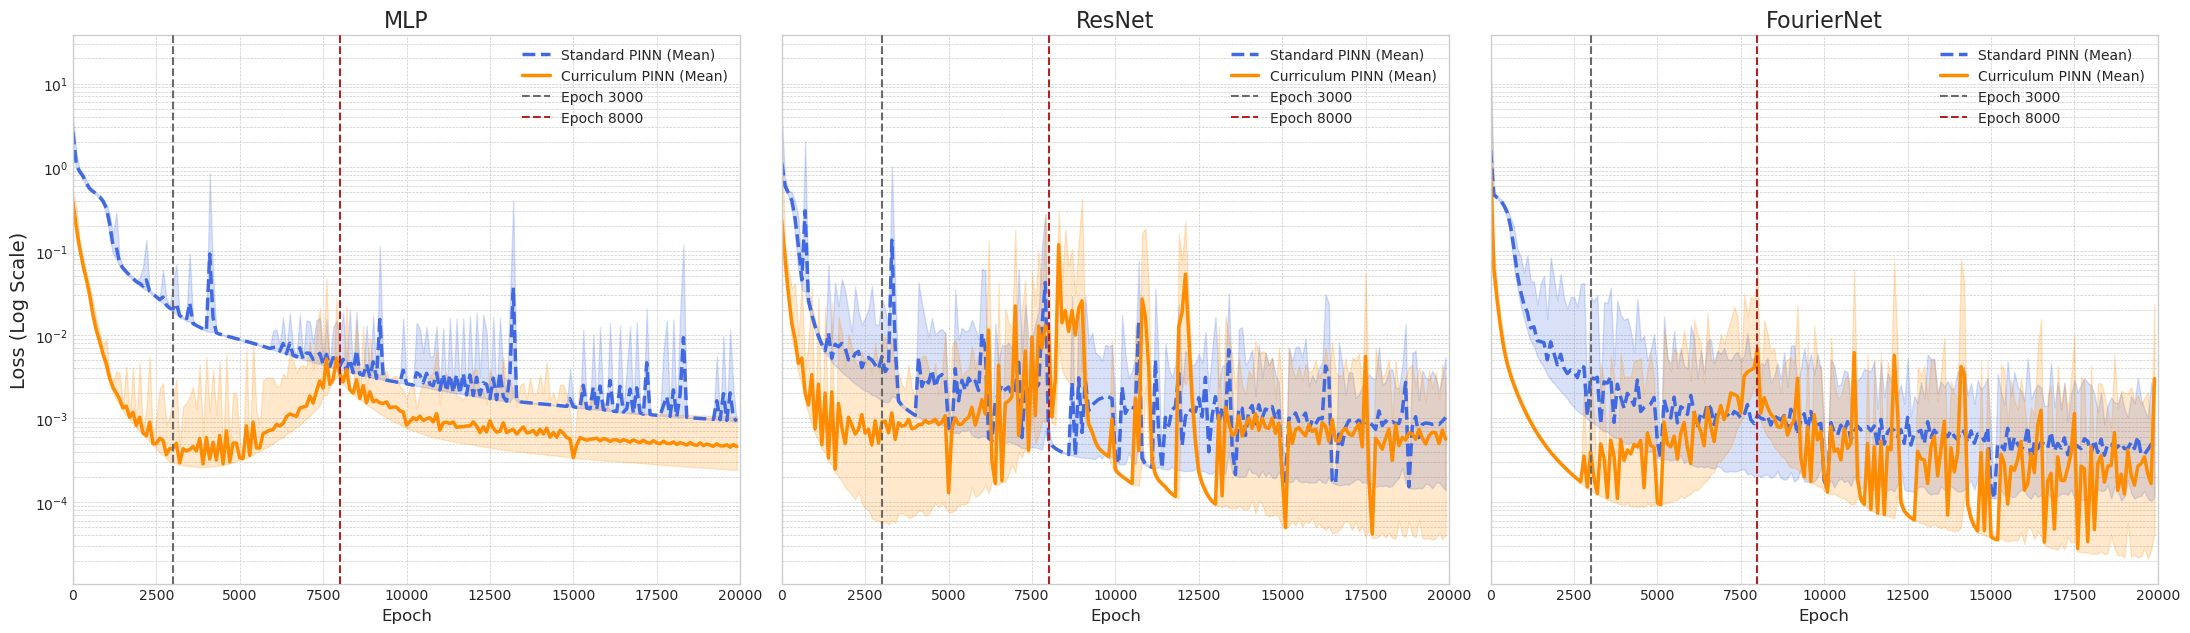


✓ 可视化完成！已在 epoch=3000 和 8000 处添加辅助线。


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 配置区域 ---

# 文件名到模型名称的映射
file_map = {
    'burgers_mlp.csv': 'MLP',
    'burgers_res.csv': 'ResNet',
    'burgers_fou.csv': 'FourierNet'
}

# 定义分组大小。每个组包含 GROUP_SIZE 个 epoch 的数据。
GROUP_SIZE = 100

# 为两种训练方法定义颜色
colors = {
    'Standard PINN': 'royalblue',
    'Curriculum PINN': 'darkorange'
}

# --- 2. 创建绘图布局 ---
# 创建一个包含 1 行 3 列的子图布局，并共享Y轴
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
# fig.suptitle('Loss Comparison with Confidence Bands and Key Epochs', fontsize=20, fontweight='bold')
plt.style.use('seaborn-v0_8-whitegrid')

# --- 3. 循环处理每个模型并绘图 ---
for i, (filename, model_name) in enumerate(file_map.items()):
    ax = axes[i]  # 选择当前子图
    print(f"--- Processing: {model_name} ({filename}) ---")
    
    try:
        df = pd.read_csv(filename)
        
        # 创建分组索引
        group_indices = np.arange(len(df)) // GROUP_SIZE
        
        # 循环处理两种训练方法 (Standard 和 Curriculum)
        for method, color in colors.items():
            loss_column = 'standard_pinn_loss' if method == 'Standard PINN' else 'curriculum_pinn_loss'
            linestyle = '--' if method == 'Standard PINN' else '-'
            
            # 分组并聚合 min, max, mean
            aggregated_data = df.groupby(group_indices).agg(
                epoch=('epoch', 'first'),
                loss_min=(loss_column, 'min'),
                loss_max=(loss_column, 'max'),
                loss_mean=(loss_column, 'mean')
            )
            
            # 绘制均值线 (zorder=2, 在填充区域之上)
            ax.plot(
                aggregated_data['epoch'], 
                aggregated_data['loss_mean'], 
                color=color, 
                linestyle=linestyle, 
                lw=2.5, 
                label=f'{method} (Mean)',
                zorder=2
            )
            
            # 绘制置信区间 (zorder=1, 在最底层)
            ax.fill_between(
                aggregated_data['epoch'], 
                aggregated_data['loss_min'], 
                aggregated_data['loss_max'], 
                color=color, 
                alpha=0.2,
                label=f'{method} (Min-Max Range)',
                zorder=1
            )

        # --- 4. 添加辅助线 ---
        # 在 epoch=3000 处添加一条灰色虚线
        ax.axvline(x=3000, color='dimgray', linestyle='--', linewidth=1.5, label='Epoch 3000', zorder=3)
        # 在 epoch=8000 处添加一条深红色虚线
        ax.axvline(x=8000, color='firebrick', linestyle='--', linewidth=1.5, label='Epoch 8000', zorder=3)

        # --- 5. 美化每个子图 ---
        ax.set_yscale('log')
        ax.set_title(model_name, fontsize=16)
        ax.set_xlabel('Epoch', fontsize=12)
        ax.grid(True, which="both", ls="--", linewidth=0.5)
        
        # 调整图例以避免重叠
        # 我们只显示均值线和辅助线的标签，隐藏置信区间的标签以简化图例
        handles, labels = ax.get_legend_handles_labels()
        # 筛选出我们想要显示的标签
        display_indices = [i for i, label in enumerate(labels) if 'Mean' in label or 'Epoch' in label]
        ax.legend([handles[i] for i in display_indices], [labels[i] for i in display_indices], fontsize=10)
        
        ax.set_xlim(0, 20000)

    except FileNotFoundError:
        print(f"[ERROR] File '{filename}' not found. Skipping.")
        ax.text(0.5, 0.5, f'{filename}\nnot found', ha='center', va='center', fontsize=12, color='red', transform=ax.transAxes)
    except Exception as e:
        print(f"[ERROR] An error occurred while processing {filename}: {e}")

# --- 6. 全局美化 ---
# 为共享的Y轴设置标签 (只需要在第一个子图上设置)
axes[0].set_ylabel('Loss (Log Scale)', fontsize=14)
# 调整布局以防止标题重叠
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 显示图像
plt.show()

print("\n✓ 可视化完成！已在 epoch=3000 和 8000 处添加辅助线。")